# Распределения вероятностей

## Модуль 1: Дискретные и непрерывные распределения

В этом ноутбуке мы рассмотрим основные распределения вероятностей, которые широко используются в статистике и машинном обучении.

### Содержание:
1. Дискретные и непрерывные случайные величины
2. Функции распределения: PMF, PDF, CDF
3. Дискретные распределения: Бернулли, Биномиальное, Пуассон
4. Непрерывные распределения: Равномерное, Нормальное, Экспоненциальное
5. Применения в реальных задачах

## 1. Дискретные и непрерывные случайные величины

**Случайная величина** — это функция, которая каждому исходу случайного эксперимента ставит в соответствие число.

### Дискретные случайные величины
Принимают countable (счётное) множество значений.

**Примеры:**
- Количество выпавших очков на кубике: $X \in \{1, 2, 3, 4, 5, 6\}$
- Количество голов при 10 бросках монеты: $X \in \{0, 1, 2, ..., 10\}$
- Количество клиентов в магазине за час: $X \in \{0, 1, 2, ...\}$

### Непрерывные случайные величины
Принимают любые значения из некоторого интервала.

**Примеры:**
- Время ожидания автобуса: $X \in [0, \infty)$
- Рост человека: $X \in [50, 250]$ см
- Температура: $X \in [-273.15, \infty)$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Настройка стиля
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print('Библиотеки успешно загружены!')

Библиотеки успешно загружены!


## 2. Функции распределения

### Для дискретных случайных величин:

**Функция вероятности (PMF - Probability Mass Function):**
$$p(x) = P(X = x)$$

Свойства:
- $p(x) \geq 0$ для всех $x$
- $\sum_{x} p(x) = 1$

**Функция распределения (CDF - Cumulative Distribution Function):**
$$F(x) = P(X \leq x) = \sum_{k \leq x} p(k)$$

### Для непрерывных случайных величин:

**Функция плотности (PDF - Probability Density Function):**
$$f(x) \geq 0, \quad \int_{-\infty}^{\infty} f(x) dx = 1$$

**Функция распределения (CDF):**
$$F(x) = P(X \leq x) = \int_{-\infty}^{x} f(t) dt$$

**Важно:** Для непрерывных случайных величин $P(X = x) = 0$ для любого $x$!

## 3. Дискретные распределения

### 3.1 Распределение Бернулли

**Описание:** Моделирует один эксперимент с двумя исходами (успех/неудача).

$$X \sim \text{Bernoulli}(p)$$

**PMF:**
$$P(X = k) = \begin{cases} p & \text{если } k = 1 \\ 1-p & \text{если } k = 0 \end{cases}$$

**Параметры:**
- $p$ — вероятность успеха

**Моменты:**
- $E[X] = p$
- $\text{Var}(X) = p(1-p)$

**Применения:**
- Подбрасывание монеты ($p = 0.5$)
- Результат клинического испытания
- Клик/не клик по рекламе

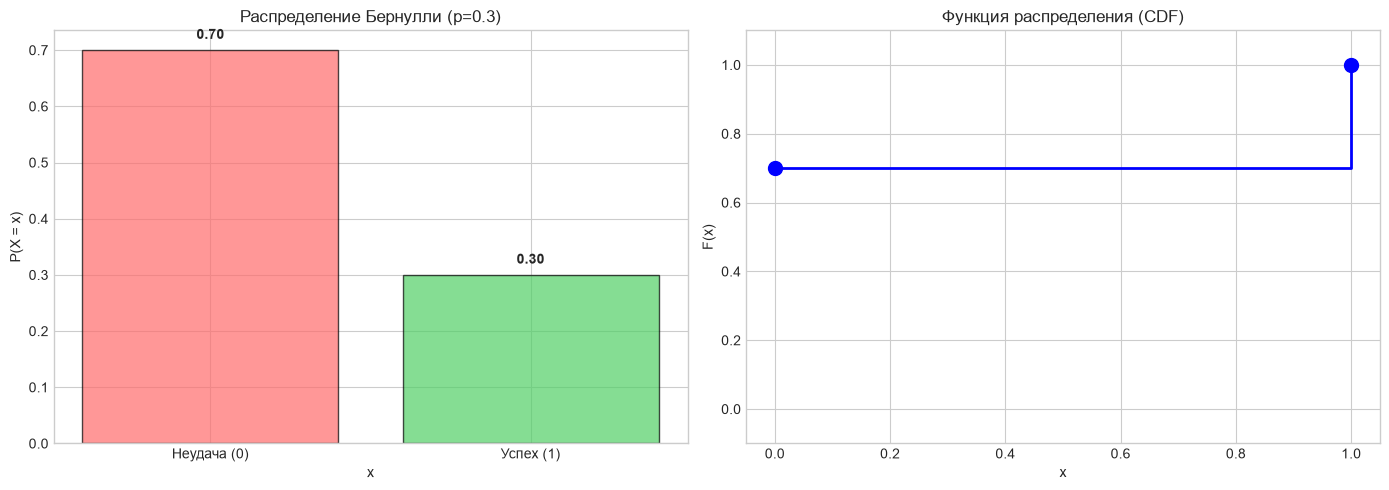

E[X] = 0.30
Var(X) = 0.2100


In [2]:
# Распределение Бернулли
p = 0.3  # Вероятность успеха

# PMF
x = np.array([0, 1])
pmf = np.array([1-p, p])

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PMF
axes[0].bar(x, pmf, color=['#ff6b6b', '#51cf66'], edgecolor='black', alpha=0.7)
axes[0].set_xlabel('x')
axes[0].set_ylabel('P(X = x)')
axes[0].set_title(f'Распределение Бернулли (p={p})')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Неудача (0)', 'Успех (1)'])
for i, v in enumerate(pmf):
    axes[0].text(i, v + 0.02, f'{v:.2f}', ha='center', fontweight='bold')

# CDF
cdf = np.cumsum(pmf)
axes[1].step(x, cdf, where='post', color='blue', linewidth=2)
axes[1].scatter(x, cdf, color='blue', s=100, zorder=5)
axes[1].set_xlabel('x')
axes[1].set_ylabel('F(x)')
axes[1].set_title('Функция распределения (CDF)')
axes[1].set_ylim(-0.1, 1.1)

plt.tight_layout()
plt.show()

# Статистики
mean = p
variance = p * (1 - p)
print(f'E[X] = {mean:.2f}')
print(f'Var(X) = {variance:.4f}')

### 3.2 Биномиальное распределение

**Описание:** Количество успехов в $n$ независимых испытаниях Бернулли.

$$X \sim \text{Binomial}(n, p)$$

**PMF:**
$$P(X = k) = \binom{n}{k} p^k (1-p)^{n-k}$$

где $\binom{n}{k} = \frac{n!}{k!(n-k)!}$ — биномиальный коэффициент.

**Параметры:**
- $n$ — количество испытаний
- $p$ — вероятность успеха в каждом испытании

**Моменты:**
- $E[X] = np$
- $\text{Var}(X) = np(1-p)$

**Применения:**
- Количество выигрышей в серии игр
- Количество дефектных деталей в партии
- Количество успешных рекламных кампаний

In [ ]:
# Биномиальное распределение
n, p = 10, 0.5  # 10 испытаний, вероятность успеха 0.5

x = np.arange(0, n + 1)
pmf = stats.binom.pmf(x, n, p)
cdf = stats.binom.cdf(x, n, p)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PMF
axes[0].bar(x, pmf, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('k')
axes[0].set_ylabel('P(X = k)')
axes[0].set_title(f'Биномиальное распределение (n={n}, p={p})')
for i, v in enumerate(pmf):
    if v > 0.05:
        axes[0].text(i, v + 0.01, f'{v:.2f}', ha='center', fontsize=8)

# CDF
axes[1].step(x, cdf, where='post', color='blue', linewidth=2)
axes[1].scatter(x, cdf, color='blue', s=50, zorder=5)
axes[1].set_xlabel('k')
axes[1].set_ylabel('F(k)')
axes[1].set_title('Функция распределения (CDF)')

plt.tight_layout()
plt.show()

# Статистики
mean = n * p
variance = n * p * (1 - p)
print(f'E[X] = np = {mean:.2f}')
print(f'Var(X) = np(1-p) = {variance:.2f}')

### 3.3 Распределение Пуассона

**Описание:** Количество событий в фиксированном интервале времени/пространства.

$$X \sim \text{Poisson}(\lambda)$$

**PMF:**
$$P(X = k) = \frac{\lambda^k e^{-\lambda}}{k!}, \quad k = 0, 1, 2, ...$$

**Параметр:**
- $\lambda > 0$ — среднее количество событий за интервал

**Моменты:**
- $E[X] = \lambda$
- $\text{Var}(X) = \lambda$ (дисперсия равна среднему!)

**Применения:**
- Количество звонков в call-центр за час
- Количество ошибок на странице текста
- Количество мутаций в ДНК

In [ ]:
# Распределение Пуассона
lam = 4  # λ = 4 события в среднем

x = np.arange(0, 15)
pmf = stats.poisson.pmf(x, lam)
cdf = stats.poisson.cdf(x, lam)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PMF
axes[0].bar(x, pmf, color='coral', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('k')
axes[0].set_ylabel('P(X = k)')
axes[0].set_title(f'Распределение Пуассона (λ={lam})')
for i, v in enumerate(pmf):
    if v > 0.05:
        axes[0].text(i, v + 0.01, f'{v:.2f}', ha='center', fontsize=8)

# CDF
axes[1].step(x, cdf, where='post', color='blue', linewidth=2)
axes[1].scatter(x, cdf, color='blue', s=50, zorder=5)
axes[1].set_xlabel('k')
axes[1].set_ylabel('F(k)')
axes[1].set_title('Функция распределения (CDF)')

plt.tight_layout()
plt.show()

# Статистики
print(f'E[X] = λ = {lam}')
print(f'Var(X) = λ = {lam}')
print(f'\nПримечание: Дисперсия равна среднему!')

## 4. Непрерывные распределения

### 4.1 Равномерное распределение

$$X \sim U(a, b)$$

**PDF:**
$$f(x) = \begin{cases} \frac{1}{b-a} & \text{если } a \leq x \leq b \\ 0 & \text{иначе} \end{cases}$$

**Моменты:**
- $E[X] = \frac{a+b}{2}$
- $\text{Var}(X) = \frac{(b-a)^2}{12}$

**Применения:**
- Генерация случайных чисел
- Моделирование неопределённости

In [ ]:
# Равномерное распределение
a, b = 2, 8

x = np.linspace(a - 1, b + 1, 1000)
pdf = stats.uniform.pdf(x, loc=a, scale=b-a)
cdf = stats.uniform.cdf(x, loc=a, scale=b-a)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PDF
axes[0].plot(x, pdf, 'b-', linewidth=2, label='PDF')
axes[0].fill_between(x, pdf, alpha=0.3)
axes[0].set_xlabel('x')
axes[0].set_ylabel('f(x)')
axes[0].set_title(f'Равномерное распределение U({a},{b})')
axes[0].axvline(x=(a+b)/2, color='red', linestyle='--', label=f'E[X]={(a+b)/2}')
axes[0].legend()

# CDF
axes[1].plot(x, cdf, 'b-', linewidth=2, label='CDF')
axes[1].set_xlabel('x')
axes[1].set_ylabel('F(x)')
axes[1].set_title('Функция распределения (CDF)')
axes[1].legend()

plt.tight_layout()
plt.show()

# Статистики
mean = (a + b) / 2
variance = (b - a)**2 / 12
print(f'E[X] = (a+b)/2 = {mean:.2f}')
print(f'Var(X) = (b-a)²/12 = {variance:.4f}')

### 4.2 Нормальное (Гауссово) распределение

$$X \sim N(\mu, \sigma^2)$$

**PDF:**
$$f(x) = \frac{1}{\sigma\sqrt{2\pi}} \exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)$$

**Параметры:**
- $\mu$ — математическое ожидание (среднее)
- $\sigma^2$ — дисперсия
- $\sigma$ — стандартное отклонение

**Свойства:**
- Симметрично относительно $\mu$
- $\mu \pm \sigma$ содержит ~68% данных
- $\mu \pm 2\sigma$ содержит ~95% данных
- $\mu \pm 3\sigma$ содержит ~99.7% данных

**Почему это важно?** Центральная предельная теорема!

In [ ]:
# Нормальное распределение
mu, sigma = 0, 1  # Стандартное нормальное

x = np.linspace(-4, 4, 1000)
pdf = stats.norm.pdf(x, mu, sigma)
cdf = stats.norm.cdf(x, mu, sigma)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PDF
axes[0].plot(x, pdf, 'b-', linewidth=2, label='N(0,1)')
axes[0].fill_between(x, pdf, alpha=0.3)

# Заштриховать области ±σ, ±2σ, ±3σ
for n_sigma, alpha, color in [(1, 0.3, 'blue'), (2, 0.2, 'green'), (3, 0.1, 'yellow')]:
    x_fill = x[(x >= -n_sigma) & (x <= n_sigma)]
    pdf_fill = stats.norm.pdf(x_fill, mu, sigma)
    axes[0].fill_between(x_fill, pdf_fill, alpha=alpha, color=color, 
                         label=f'±{n_sigma}σ')

axes[0].set_xlabel('x')
axes[0].set_ylabel('f(x)')
axes[0].set_title('Стандартное нормальное распределение N(0,1)')
axes[0].legend()

# CDF
axes[1].plot(x, cdf, 'b-', linewidth=2, label='CDF')
axes[1].axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Median=0.5')
axes[1].axvline(x=0, color='red', linestyle='--', alpha=0.5)
axes[1].set_xlabel('x')
axes[1].set_ylabel('F(x)')
axes[1].set_title('Функция распределения (CDF)')
axes[1].legend()

plt.tight_layout()
plt.show()

# Правило трёх сигм
print('Правило трёх сигм:')
for n in [1, 2, 3]:
    prob = stats.norm.cdf(n) - stats.norm.cdf(-n)
    print(f'  P(μ ± {n}σ) = {prob:.4f} ({prob*100:.1f}%)')

### 4.3 Экспоненциальное распределение

$$X \sim \text{Exp}(\lambda)$$

**PDF:**
$$f(x) = \lambda e^{-\lambda x}, \quad x \geq 0$$

**Параметр:**
- $\lambda > 0$ — интенсивность (rate parameter)

**Моменты:**
- $E[X] = \frac{1}{\lambda}$
- $\text{Var}(X) = \frac{1}{\lambda^2}$

**Свойство отсутствия памяти:**
$$P(X > s + t | X > s) = P(X > t)$$

**Применения:**
- Время между событиями (время ожидания)
- Время жизни компонентов
- Интервалы между клиентами

In [ ]:
# Экспоненциальное распределение
lam = 0.5  # λ = 0.5

x = np.linspace(0, 10, 1000)
pdf = stats.expon.pdf(x, scale=1/lam)
cdf = stats.expon.cdf(x, scale=1/lam)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PDF
axes[0].plot(x, pdf, 'r-', linewidth=2, label=f'Exp(λ={lam})')
axes[0].fill_between(x, pdf, alpha=0.3, color='red')
axes[0].axvline(x=1/lam, color='blue', linestyle='--', label=f'E[X]={1/lam}')
axes[0].set_xlabel('x')
axes[0].set_ylabel('f(x)')
axes[0].set_title(f'Экспоненциальное распределение (λ={lam})')
axes[0].legend()

# CDF
axes[1].plot(x, cdf, 'r-', linewidth=2, label='CDF')
axes[1].axhline(y=0.5, color='blue', linestyle='--', alpha=0.5, label='Median')
axes[1].set_xlabel('x')
axes[1].set_ylabel('F(x)')
axes[1].set_title('Функция распределения (CDF)')
axes[1].legend()

plt.tight_layout()
plt.show()

# Статистики
print(f'E[X] = 1/λ = {1/lam:.2f}')
print(f'Var(X) = 1/λ² = {1/lam**2:.2f}')

# Демонстрация свойства отсутствия памяти
s, t = 2, 3
p_x_gt_s_plus_t = 1 - stats.expon.cdf(s + t, scale=1/lam)
p_x_gt_s = 1 - stats.expon.cdf(s, scale=1/lam)
p_x_gt_t = 1 - stats.expon.cdf(t, scale=1/lam)

print(f'\nСвойство отсутствия памяти:')
print(f'P(X > {s+t} | X > {s}) = P(X > {s+t}) / P(X > {s}) = {p_x_gt_s_plus_t/p_x_gt_s:.4f}')
print(f'P(X > {t}) = {p_x_gt_t:.4f}')
print(f'Совпадают? {np.isclose(p_x_gt_s_plus_t/p_x_gt_s, p_x_gt_t)}')

## 5. Сравнение распределений

Давайте сравним все рассмотренные распределения на одном графике.

In [ ]:
# Сравнение дискретных распределений
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Бернулли
p = 0.3
x_bern = np.array([0, 1])
pmf_bern = np.array([1-p, p])
axes[0, 0].bar(x_bern, pmf_bern, color='steelblue', alpha=0.7)
axes[0, 0].set_title(f'Бернулли (p={p})')
axes[0, 0].set_xlabel('x')
axes[0, 0].set_ylabel('P(X=x)')

# Биномиальное
n, p = 10, 0.5
x_binom = np.arange(0, n+1)
pmf_binom = stats.binom.pmf(x_binom, n, p)
axes[0, 1].bar(x_binom, pmf_binom, color='coral', alpha=0.7)
axes[0, 1].set_title(f'Биномиальное (n={n}, p={p})')
axes[0, 1].set_xlabel('k')
axes[0, 1].set_ylabel('P(X=k)')

# Пуассон
lam = 4
x_pois = np.arange(0, 15)
pmf_pois = stats.poisson.pmf(x_pois, lam)
axes[0, 2].bar(x_pois, pmf_pois, color='green', alpha=0.7)
axes[0, 2].set_title(f'Пуассон (λ={lam})')
axes[0, 2].set_xlabel('k')
axes[0, 2].set_ylabel('P(X=k)')

# Равномерное
a, b = 0, 10
x_unif = np.linspace(a-1, b+1, 1000)
pdf_unif = stats.uniform.pdf(x_unif, loc=a, scale=b-a)
axes[1, 0].plot(x_unif, pdf_unif, 'b-', linewidth=2)
axes[1, 0].fill_between(x_unif, pdf_unif, alpha=0.3)
axes[1, 0].set_title(f'Равномерное U({a},{b})')
axes[1, 0].set_xlabel('x')
axes[1, 0].set_ylabel('f(x)')

# Нормальное
mu, sigma = 0, 1
x_norm = np.linspace(-4, 4, 1000)
pdf_norm = stats.norm.pdf(x_norm, mu, sigma)
axes[1, 1].plot(x_norm, pdf_norm, 'r-', linewidth=2)
axes[1, 1].fill_between(x_norm, pdf_norm, alpha=0.3, color='red')
axes[1, 1].set_title(f'Нормальное N({mu},{sigma}²)')
axes[1, 1].set_xlabel('x')
axes[1, 1].set_ylabel('f(x)')

# Экспоненциальное
lam = 0.5
x_exp = np.linspace(0, 10, 1000)
pdf_exp = stats.expon.pdf(x_exp, scale=1/lam)
axes[1, 2].plot(x_exp, pdf_exp, 'g-', linewidth=2)
axes[1, 2].fill_between(x_exp, pdf_exp, alpha=0.3, color='green')
axes[1, 2].set_title(f'Экспоненциальное (λ={lam})')
axes[1, 2].set_xlabel('x')
axes[1, 2].set_ylabel('f(x)')

plt.tight_layout()
plt.show()

## Упражнения

### Упражнение 1: Биномиальное распределение
В магазине 30% клиентов делают покупку. Если в магазин приходят 20 клиентов:
1. Какова вероятность, что ровно 5 из них сделают покупку?
2. Какова вероятность, что не более 8 сделают покупку?
3. Каково среднее количество покупателей и дисперсия?

### Упражнение 2: Распределение Пуассона
В call-центр поступает в среднем 5 звонков в час:
1. Какова вероятность, что за час поступит ровно 3 звонка?
2. Какова вероятность, что за час поступит более 7 звонков?

### Упражнение 3: Нормальное распределение
Рост студентов распределён нормально с $\mu = 170$ см и $\sigma = 10$ см:
1. Какова вероятность, что случайный студент имеет рост от 160 до 180 см?
2. Какой рост имеют 5% самых высоких студентов?

### Упражнение 4: Экспоненциальное распределение
Время между клиентами в банке распределено экспоненциально с $\lambda = 0.2$ (клиентов в минуту):
1. Каково среднее время между клиентами?
2. Какова вероятность, что следующий клиент придёт через более чем 10 минут?

---

**Решения** можно найти в ноутбуке `solutions/02_Solutions.ipynb`